In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import warnings
import pmdarima as pm
import pandas as pd
import gymnasium as gym
import random
from gymnasium import spaces
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error

input library pmd arima


In [3]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 11.6 MB/s eta 0:00:00


# Input data pzem (sementara simulasi dari random np)

Contoh 5 Data Pertama:
                     Temperature      Kipas        HP     Laptop     Setrika  \
2024-01-01 00:00:00    28.248357  34.922511  5.133860  45.240336  215.142747   
2024-01-01 01:00:00    28.967551  35.830077  6.922730  47.011865  194.356953   
2024-01-01 02:00:00    30.326366  37.120928  7.030192  46.723983  225.802973   
2024-01-01 03:00:00    31.593030  37.863030  7.053013  48.509662  208.737578   
2024-01-01 04:00:00    31.349934  37.529992  5.400676  48.157157  219.240820   

                        Magicom  
2024-01-01 00:00:00  288.796395  
2024-01-01 01:00:00  287.430548  
2024-01-01 02:00:00  282.347947  
2024-01-01 03:00:00  282.639806  
2024-01-01 04:00:00  294.098566  


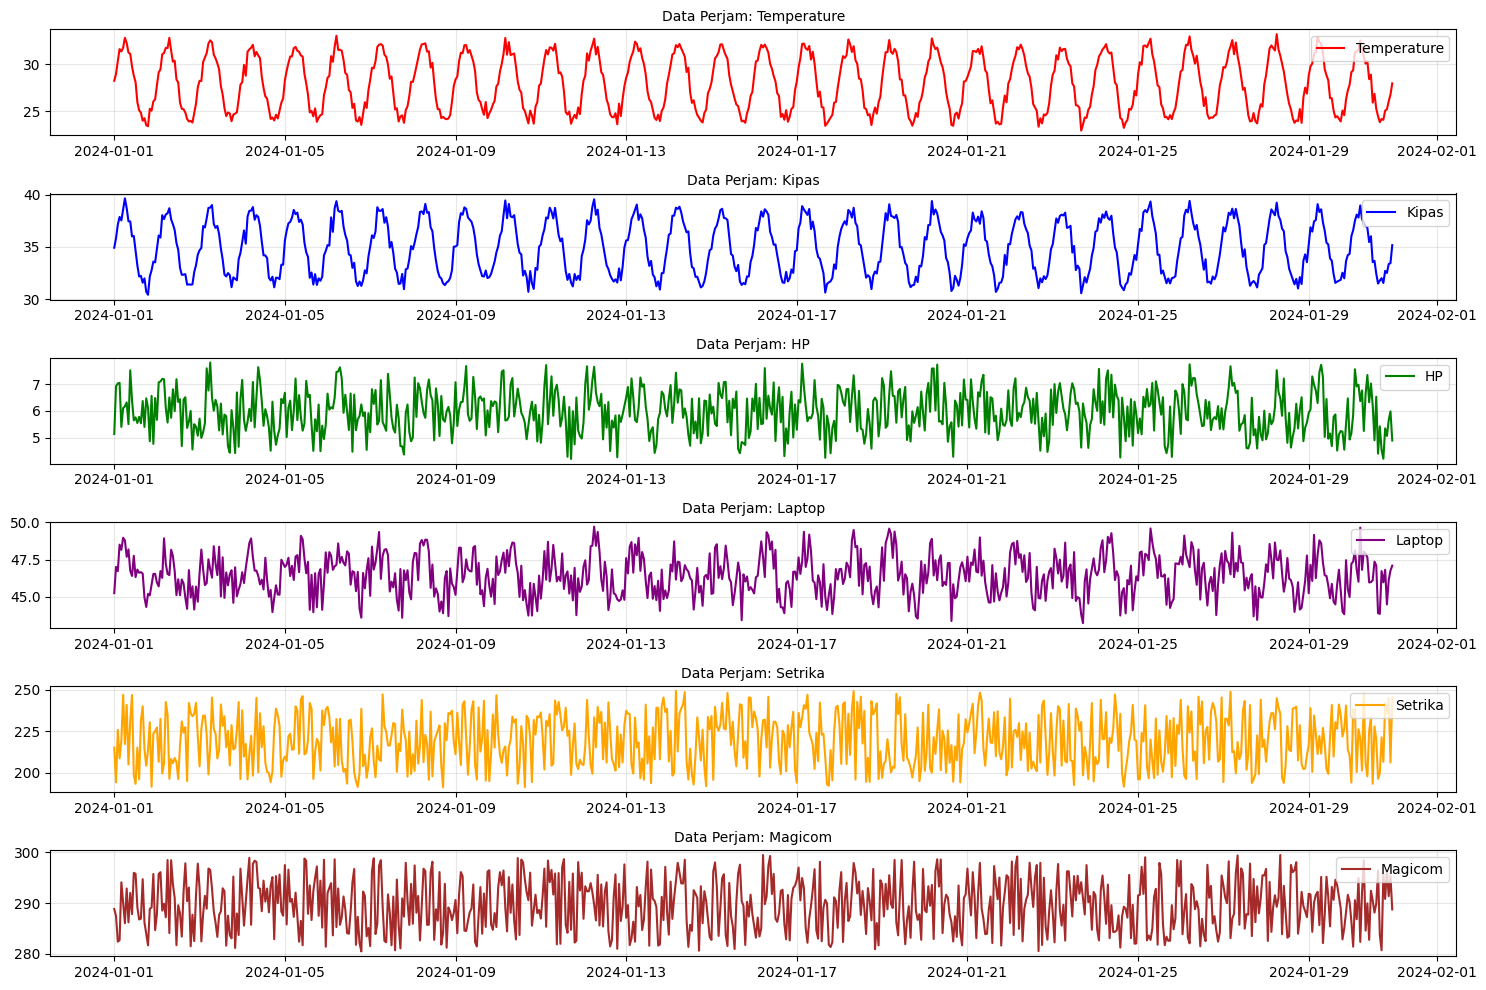

In [5]:
np.random.seed(42)
hours = 30 * 24
dates = pd.date_range(start='2024-01-01', periods=hours, freq='H')
daily_pattern = np.sin(np.linspace(0, 30 * 2 * np.pi, hours))
temperature = 28 + (4 * daily_pattern) + np.random.normal(0, 0.5, hours)
def generate_device_load(temp_data, min_val, max_val, correlation_strength=0.8, noise_level=1.0):
    temp_norm = (temp_data - temp_data.min()) / (temp_data.max() - temp_data.min())
    base_load = temp_norm * correlation_strength
    random_noise = np.random.rand(len(temp_data)) * (1 - correlation_strength)
    final_raw = base_load + random_noise
    final_scaled = min_val + final_raw * (max_val - min_val)

    # Pastikan tidak ada yang bocor keluar range (Clipping)
    return np.clip(final_scaled, min_val, max_val)

# A. Kipas (Min 30, Max 40) - Korelasi Suhu TINGGI
load_kipas = generate_device_load(temperature, 30, 40, correlation_strength=0.9)

# B. HP (Min 4, Max 8) - Korelasi Suhu SEDANG (Baterai panas) + Acak
load_hp = generate_device_load(temperature, 4, 8, correlation_strength=0.4)

# C. Laptop (Min 43, Max 50) - Korelasi Suhu SEDANG (Fan laptop) + Pola Kerja
load_laptop = generate_device_load(temperature, 43, 50, correlation_strength=0.5)

# D. Setrika (Min 190, Max 250) - Korelasi Suhu RENDAH (Hampir konstan/acak)
load_setrika = generate_device_load(temperature, 190, 250, correlation_strength=0.1)

# E. Magicom (Min 280, Max 300) - Korelasi Suhu RENDAH
load_magicom = generate_device_load(temperature, 280, 300, correlation_strength=0.1)

# Buat DataFrame
df = pd.DataFrame({
    'Temperature': temperature,
    'Kipas': load_kipas,
    'HP': load_hp,
    'Laptop': load_laptop,
    'Setrika': load_setrika,
    'Magicom': load_magicom
}, index=dates)

# Cek 5 data teratas
print("Contoh 5 Data Pertama:")
print(df.head())

# Visualisasi Data Mentah (Plotting)
plt.figure(figsize=(15, 10))
features = ['Temperature', 'Kipas', 'HP', 'Laptop', 'Setrika', 'Magicom']
colors = ['red', 'blue', 'green', 'purple', 'orange', 'brown']

for i, col in enumerate(features):
    plt.subplot(6, 1, i+1)
    plt.plot(df.index, df[col], color=colors[i], label=col)
    plt.title(f'Data Perjam: {col}', fontsize=10)
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:

def check_stationarity(timeseries, title):
    print(f"\n--- Uji ADF: {title} ---")
    # Dropna penting karena ADF error jika ada data kosong (NaN)
    result = adfuller(timeseries.dropna())

    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')

    if result[1] <= 0.05:
        print("Kesimpulan: Data STASIONER (Tolak H0)")
        return True
    else:
        print("Kesimpulan: Data TIDAK STASIONER (Gagal Tolak H0) -> Perlu Differencing")
        return False

# ========================================================
# MEMANGGIL UNTUK SEMUA PERANGKAT (PAKAI LOOP)
# ========================================================

# list nama kolom perangkat di DataFrame
daftar_perangkat = ['Kipas', 'HP', 'Laptop', 'Setrika', 'Magicom']

print("MEMULAI PENGECEKAN OTOMATIS...")

for nama in daftar_perangkat:
    # Panggil fungsi tadi, ganti df['Kipas'] menjadi df[nama]
    check_stationarity(df[nama], f"Data Asli {nama}")

MEMULAI PENGECEKAN OTOMATIS...

--- Uji ADF: Data Asli Kipas ---
ADF Statistic: -8.5809
p-value: 0.0000
Kesimpulan: Data STASIONER (Tolak H0)

--- Uji ADF: Data Asli HP ---
ADF Statistic: -6.9958
p-value: 0.0000
Kesimpulan: Data STASIONER (Tolak H0)

--- Uji ADF: Data Asli Laptop ---
ADF Statistic: -6.5220
p-value: 0.0000
Kesimpulan: Data STASIONER (Tolak H0)

--- Uji ADF: Data Asli Setrika ---
ADF Statistic: -24.9518
p-value: 0.0000
Kesimpulan: Data STASIONER (Tolak H0)

--- Uji ADF: Data Asli Magicom ---
ADF Statistic: -26.7285
p-value: 0.0000
Kesimpulan: Data STASIONER (Tolak H0)


=== MODUL BELAJAR: PLOT ACF & PACF ===


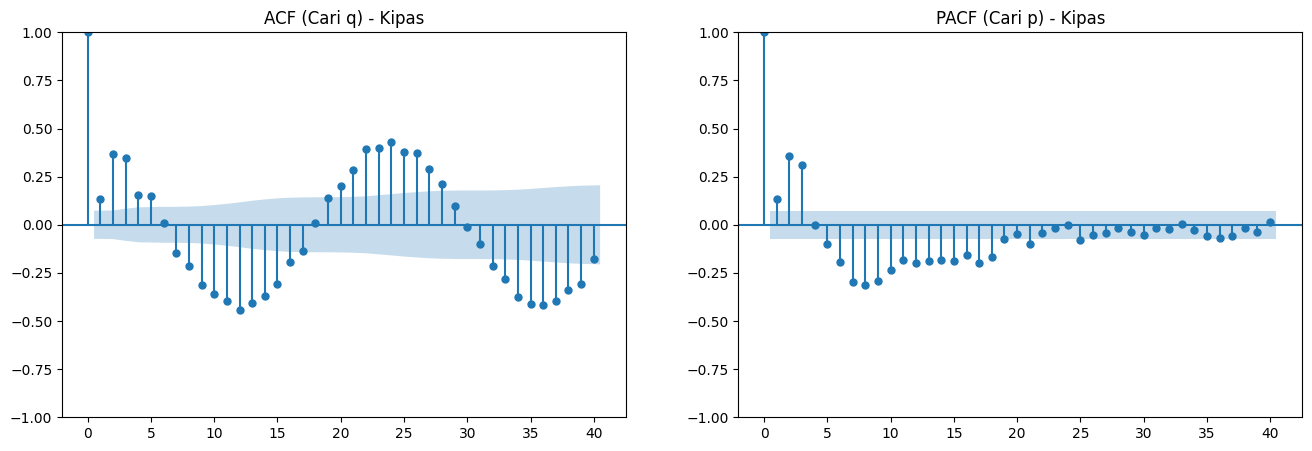

--------------------------------------------------------------------------------


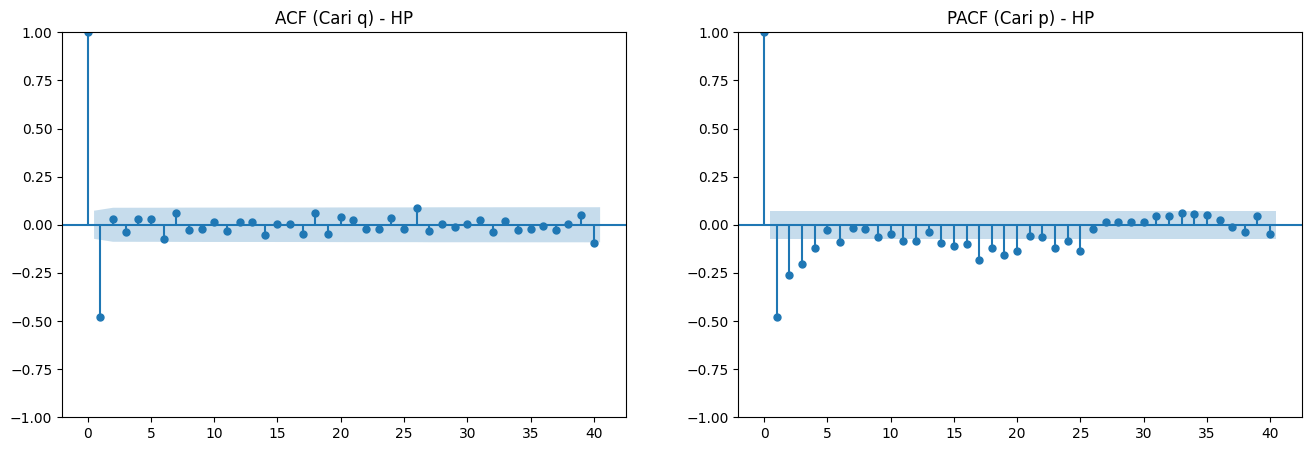

--------------------------------------------------------------------------------


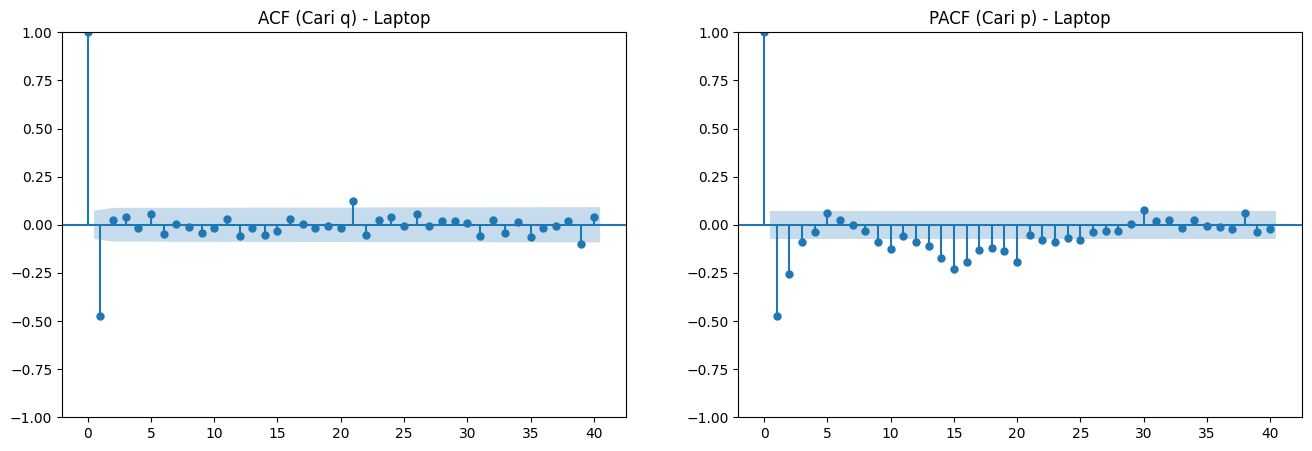

--------------------------------------------------------------------------------


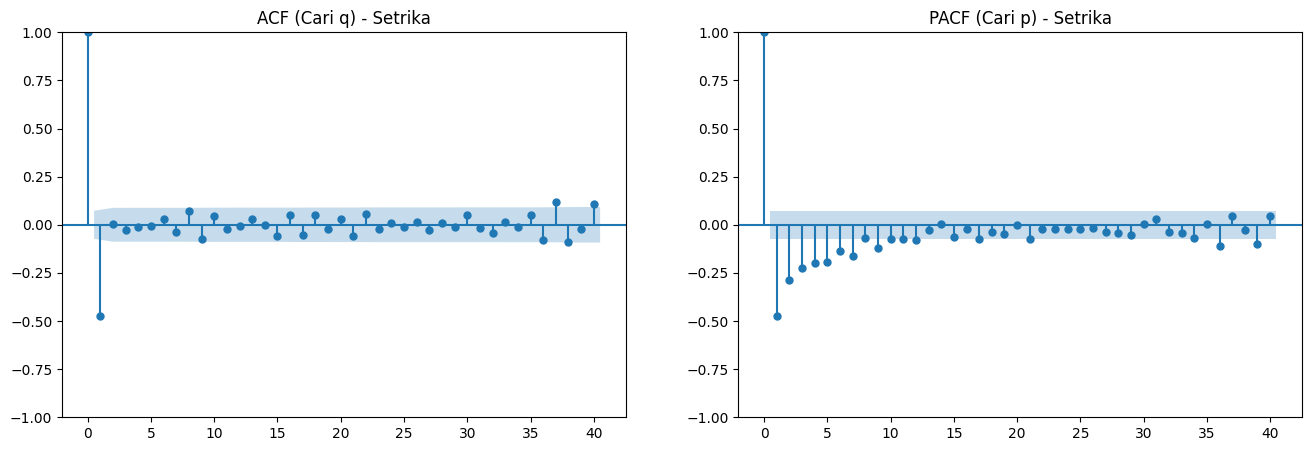

--------------------------------------------------------------------------------


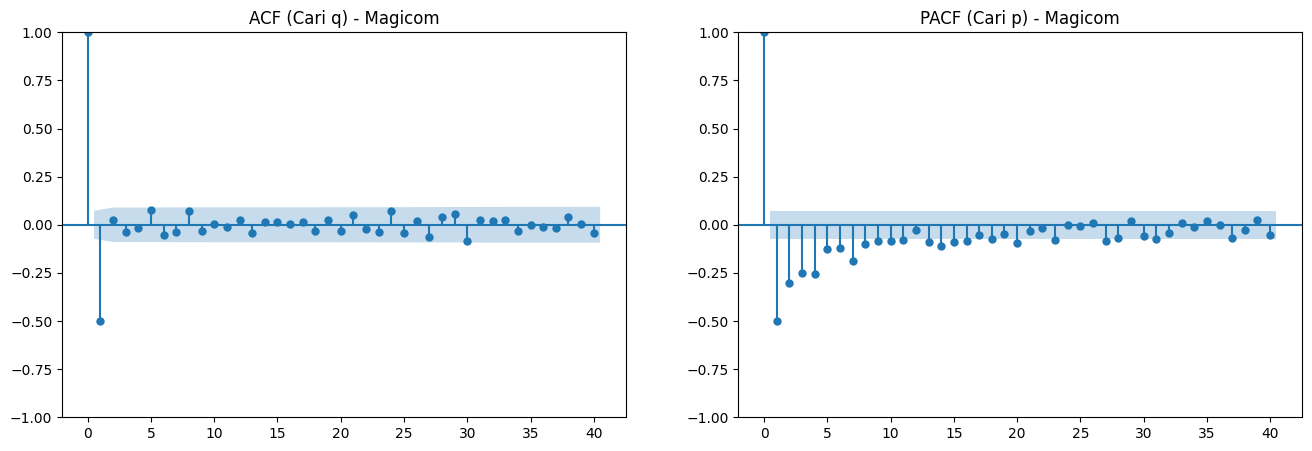

--------------------------------------------------------------------------------


In [7]:
daftar_perangkat = ['Kipas', 'HP', 'Laptop', 'Setrika', 'Magicom']

print("=== MODUL BELAJAR: PLOT ACF & PACF ===")

for nama in daftar_perangkat:
    # pakai .diff() agar data stasioner (lebih mudah baca pola p dan q nya)
    data_to_plot = df[nama].diff().dropna()

    # Membuat Kanvas (Kiri: ACF, Kanan: PACF)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    # 1. Plot ACF (Autocorrelation) -> Untuk cari q (MA)
    # lags=40 artinya dpt melihat hubungan sampai 40 jam ke belakang
    plot_acf(data_to_plot, lags=40, ax=ax1, title=f'ACF (Cari q) - {nama}')

    # 2. Plot PACF (Partial Autocorrelation) -> Untuk cari p (AR)
    plot_pacf(data_to_plot, lags=40, ax=ax2, title=f'PACF (Cari p) - {nama}')

    plt.show()
    print("-" * 80)

In [ ]:

# List perangkat
daftar_perangkat = ['Kipas', 'HP', 'Laptop', 'Setrika', 'Magicom']
variable_eksogen = df[['Temperature']] # Variabel X

print("=== MEMULAI PENCARIAN MODEL OTOMATIS (AUTO ARIMA) ===")
print("Note: Proses ini mungkin memakan waktu karena komputer melakukan ribuan perhitungan.\n")

best_models = {}

for nama in daftar_perangkat:
    print(f"Sedang mencari model terbaik untuk: {nama}...")

    # Target Variable (Y)
    target_variable = df[nama]

    # ---   penjelasan fungsi AUTO_ARIMA ---
    # m = 24 --> Karena data perjam (Seasonal periodenya 24 jam)
    # seasonal = True --> Wajib True karena beban listrik ada pola harian
    # stepwise = True --> Agar pencarian lebih cepat (smart search)
    # X = variable_eksogen --> Memasukkan suhu sebagai faktor penentu

    model = pm.auto_arima(y=target_variable,
                          X=variable_eksogen,
                          start_p=0, start_q=0,
                          max_p=3, max_q=3, # Batas atas pencarian (bisa dinaikkan)
                          m=24,             # Siklus musiman (24 jam)
                          seasonal=True,    # Aktifkan mode seasonal
                          d=None,           # Biarkan dia hitung otomatis butuh diff atau tidak
                          D=1,              # Seasonal diff biasanya butuh 1 kali (opsional, bisa None)
                          trace=True,       # Tampilkan proses pencarian di layar
                          error_action='ignore',
                          suppress_warnings=True,
                          stepwise=True)

    print(f"✅ Selesai! Model terbaik untuk {nama}: {model.order} Seasonal{model.seasonal_order}")
    print("-" * 50)

    # Simpan hasil summary untuk dianalisis
    best_models[nama] = model

# === MENAMPILKAN RINGKASAN AKHIR ===
print("\n" + "="*40)
print("REKAPITULASI HASIL AUTO_ARIMA")
print("="*40)

for nama, model in best_models.items():
    print(f"\n--- {nama} ---")
    # Menampilkan parameter (p,d,q) dan (P,D,Q,s)
    print(f"Order ARIMA    : {model.order}")
    print(f"Seasonal Order : {model.seasonal_order}")
    print(f"AIC Score      : {model.aic():.2f} (Semakin kecil semakin bagus)")

    # Tampilkan signifikansi Suhu (Temperature)
    # Kita intip parameter modelnya
    params = model.params()
    if 'Temperature' in params.index:
        coef_temp = params['Temperature']
        print(f"Koefisien Suhu : {coef_temp:.4f}")
    elif 'X' in params.index: # Kadang pmdarima menamainya 'X'
        coef_temp = params['X']
        print(f"Koefisien Suhu : {coef_temp:.4f}")

=== MEMULAI PENCARIAN MODEL OTOMATIS (AUTO ARIMA) ===
Note: Proses ini mungkin memakan waktu karena komputer melakukan ribuan perhitungan.

Sedang mencari model terbaik untuk: Kipas...
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(1,1,1)[24] intercept   : AIC=inf, Time=6.70 sec
 ARIMA(0,0,0)(0,1,0)[24] intercept   : AIC=752.607, Time=0.20 sec
 ARIMA(1,0,0)(1,1,0)[24] intercept   : AIC=554.285, Time=3.12 sec
 ARIMA(0,0,1)(0,1,1)[24] intercept   : AIC=inf, Time=6.22 sec
 ARIMA(0,0,0)(0,1,0)[24]             : AIC=750.639, Time=0.68 sec
 ARIMA(1,0,0)(0,1,0)[24] intercept   : AIC=752.489, Time=0.73 sec
 ARIMA(1,0,0)(2,1,0)[24] intercept   : AIC=465.914, Time=10.65 sec
 ARIMA(1,0,0)(2,1,1)[24] intercept   : AIC=inf, Time=25.12 sec
 ARIMA(1,0,0)(1,1,1)[24] intercept   : AIC=inf, Time=6.11 sec
 ARIMA(0,0,0)(2,1,0)[24] intercept   : AIC=467.424, Time=8.34 sec
 ARIMA(2,0,0)(2,1,0)[24] intercept   : AIC=465.896, Time=15.71 sec
 ARIMA(2,0,0)(1,1,0)[24] intercept   : AIC=552.964, Time=4.

input ulang library

dalam konfigurasi order model diisi dengan ouput model dari atas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# KONFIGURASI ORDER MODEL
# ==========================================
model_configs = {
    'Kipas': {'order': (2, 0, 0), 'seasonal': (2, 1, 0, 24)},
    'Laptop': {'order': (0, 0, 0), 'seasonal': (2, 1, 0, 24)},
    'HP': {'order': (0, 0, 0), 'seasonal': (2, 1, 0, 24)},
    'Setrika': {'order': (0, 0, 0), 'seasonal': (0, 0, 0, 24)},
    'Magicom': {'order': (0, 0, 0), 'seasonal': (0, 0, 0, 24)}
}

# ==========================================
# PROSES TRAINING & EVALUASI
# ==========================================
print("=== MULAI TRAINING & TESTING ===")
print(f"Total Data: {len(df)} jam")

# Split Data (80% Train, 20% Test)
train_size = int(len(df) * 0.8)
train_idx = df.index[:train_size]
test_idx = df.index[train_size:]

# [TAMBAHAN PENTING] Definisi test_data agar tidak error 'not defined'
test_data = df.iloc[train_size:].copy()

# Wadah penyimpanan
preds_dict = {}
results_metrics = {}

for nama, config in model_configs.items():
    print(f"Training Model untuk: {nama}...")

    # 1. Siapkan Data
    y_train = df[nama].iloc[:train_size]
    y_test = df[nama].iloc[train_size:] # Sama dengan test_data[nama]

    X_train = df[['Temperature']].iloc[:train_size]
    X_test = df[['Temperature']].iloc[train_size:]

    # 2. Define & Fit Model SARIMAX
    model = SARIMAX(endog=y_train,
                    exog=X_train,
                    order=config['order'],
                    seasonal_order=config['seasonal'],
                    enforce_stationarity=False,
                    enforce_invertibility=False)

    model_fit = model.fit(disp=False)

    # 3. Forecasting
    forecast_result = model_fit.get_forecast(steps=len(y_test), exog=X_test)
    y_pred = forecast_result.predicted_mean
    y_pred.index = test_idx

    # Hindari prediksi negatif
    y_pred = y_pred.clip(lower=0)

    # Simpan ke dictionary (PENTING)
    preds_dict[nama] = y_pred

    # 4. Evaluasi
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    results_metrics[nama] = {'RMSE': rmse, 'MAE': mae}
    print(f"   --> Selesai. RMSE: {rmse:.2f} | MAE: {mae:.2f}")

    # 5. Visualisasi
    plt.figure(figsize=(12, 4))
    plt.plot(y_test.index[:100], y_test.values[:100], label='Aktual (Real)', color='blue', alpha=0.7)
    plt.plot(y_pred.index[:100], y_pred.values[:100], label='Prediksi SARIMAX', color='red', linestyle='--')
    plt.title(f'Prediksi vs Aktual: {nama} (Order {config["order"]})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# ==========================================
# RANGKUMAN HASIL
# ==========================================
print("\n" + "="*30)
print("REKAPITULASI ERROR")
print("="*30)
df_res = pd.DataFrame(results_metrics).T
print(df_res)

# [TAMBAHAN PENTING] Membuat df_pred
df_pred = pd.DataFrame(preds_dict, index=test_idx)

print("\n✅ Variabel 'test_data' dan 'df_pred' sudah siap. Silakan lanjut ke kode RL.")

coding rl belum fix (masih perlu belajar lagi)

In [1]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# 1. PERSIAPAN DATA (FOKUS KE WATT)
# ==========================================
print("=== 1. MENYIAPKAN DATA BEBAN (WATT) ===")

# Ambil data prediksi SARIMAX
df_rl_watt = df_pred.copy()

# Ambil Suhu Asli (Untuk kenyamanan Kipas)
df_rl_watt['Temperature'] = test_data['Temperature'].values


# Beban puncak total bisa sampai ~600W. Kita set batas di 400W.
BATAS_DAYA_RUMAH = 400 # Watt


# ==========================================
# 2. DEFINISI LINGKUNGAN (WATT LIMITER)
# ==========================================
class PowerLimitGymEnv(gym.Env):
    def __init__(self, data, max_watt):
        super(PowerLimitGymEnv, self).__init__()

        self.data = data.reset_index(drop=True)
        self.max_watt = max_watt # Batas MCB / Sekring
        self.n_steps = len(self.data)
        self.current_step = 0

        # ACTION SPACE (4 Aksi)
        # 0: Semua Nyala, 1: Cut Setrika, 2: Cut Kipas, 3: Cut Keduanya
        self.action_space = spaces.Discrete(4)

        # OBSERVATION SPACE
        # [Suhu(3), Status_Overload(2), Status_Setrika(2)]
        # Status_Overload: 0=Aman, 1=Bahaya (Mendekati batas)
        self.observation_space = spaces.MultiDiscrete([3, 2, 2])

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = 0
        return self._get_observation(), {}

    def _get_observation(self):
        if self.current_step >= len(self.data):
             return np.array([0, 0, 0], dtype=np.int32)

        row = self.data.iloc[self.current_step]

        # 1. Level Suhu
        if row['Temperature'] < 26: temp = 0
        elif row['Temperature'] < 29: temp = 1
        else: temp = 2

        # 2. Prediksi Beban Total Murni (Tanpa intervensi)
        potential_load = row['Kipas'] + row['Setrika'] + row['HP'] + row['Laptop'] + row['Magicom']

        # Apakah prediksi beban melebihi batas?
        is_overload = 1 if potential_load > self.max_watt else 0

        # 3. Status Setrika
        ironing = 1 if row['Setrika'] > 50 else 0

        return np.array([temp, is_overload, ironing], dtype=np.int32)

    def step(self, action):
        row = self.data.iloc[self.current_step]

        # Data Beban Awal
        load_kipas = row['Kipas']
        load_setrika = row['Setrika']
        load_base = row['HP'] + row['Laptop'] + row['Magicom'] # Beban yang gabisa dimatiin
        temp = row['Temperature']

        real_kipas = load_kipas
        real_setrika = load_setrika
        comfort_penalty = 0

        # --- LOGIKA AKSI (CUTTING) ---
        # Aksi 1 & 3: Cut Setrika (Hemat Besar ~200W)
        if action in [1, 3] and load_setrika > 0:
            real_setrika = 0
            comfort_penalty += 500 # User Kesal

        # Aksi 2 & 3: Cut Kipas (Hemat Kecil ~40W)
        if action in [2, 3] and load_kipas > 0:
            real_kipas = 0
            if temp > 29: comfort_penalty += 2000 # Panas banget
            elif temp > 26: comfort_penalty += 500

        # --- HITUNG TOTAL WATT ---
        total_watt_used = real_kipas + real_setrika + load_base

        # --- REWARD FUNCTION (WATT BASED) ---
        overload_penalty = 0

        # Jika Watt MELEBIHI batas, beri hukuman SANGAT BERAT
        # Ini simulasi "Listrik Anjlok/Jepret"
        if total_watt_used > self.max_watt:
            diff = total_watt_used - self.max_watt
            # Hukuman dikali 100 per Watt yang kelebihan
            overload_penalty = diff * 100

        # Total Reward = -(Hukuman Overload + Hukuman Tidak Nyaman)
        # Agen tidak peduli harga, dia cuma peduli: JANGAN LEWAT BATAS & JANGAN BIKIN MARAH
        reward = -(overload_penalty + comfort_penalty)

        info = {
            'real_watt': total_watt_used,
            'limit': self.max_watt,
            'overload': 1 if total_watt_used > self.max_watt else 0
        }

        self.current_step += 1
        terminated = self.current_step >= self.n_steps - 1
        truncated = False

        if not terminated:
            next_obs = self._get_observation()
        else:
            next_obs = np.array([0, 0, 0], dtype=np.int32)

        return next_obs, reward, terminated, truncated, info

# ==========================================
# 3. TRAINING LOOP
# ==========================================
print("\n=== 2. TRAINING AGEN===")
env = PowerLimitGymEnv(df_rl_watt, max_watt=BATAS_DAYA_RUMAH)
q_table = np.zeros((3, 2, 2, 4)) # [Suhu, OverloadStatus, Setrika, Aksi]

alpha = 0.1
gamma = 0.9
epsilon = 1.0
episodes = 1000

for ep in range(episodes):
    state, _ = env.reset()
    state = tuple(state)
    done = False
    while not done:
        if random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        next_obs, reward, term, trunc, _ = env.step(action)
        next_state = tuple(next_obs)
        done = term or trunc

        old = q_table[state][action]
        next_max = np.max(q_table[next_state])
        q_table[state][action] = (1 - alpha) * old + alpha * (reward + gamma * next_max)
        state = next_state

    epsilon = max(0.01, epsilon * 0.99)

print("✅ Training Selesai.")

# ==========================================
# 4. VISUALISASI HASIL (WATT vs LIMIT)
# ==========================================
print("\n=== 3. PLOTTING GRAFIK DAYA ===")
state, _ = env.reset()
state = tuple(state)
done = False

hist_total_watt_rl = []
hist_total_watt_asli = []
hist_limit = []

# Hitung Watt Asli (Tanpa kontrol)
df_rl_watt['Total_Asli'] = df_rl_watt['Kipas'] + df_rl_watt['Setrika'] + df_rl_watt['HP'] + df_rl_watt['Laptop'] + df_rl_watt['Magicom']
watt_asli_values = df_rl_watt['Total_Asli'].values

limit = 100
step = 0
while not done and step < limit:
    action = np.argmax(q_table[state])
    next_obs, _, term, trunc, info = env.step(action)

    hist_total_watt_rl.append(info['real_watt'])
    hist_limit.append(info['limit'])

    state = tuple(next_obs)
    done = term or trunc
    step += 1

plt.figure(figsize=(12, 6))

# Plot Utama: Total Watt
plt.plot(watt_asli_values[:limit], label='Total Watt (Tanpa Kontrol)', color='gray', alpha=0.5, linestyle='--')
plt.plot(hist_total_watt_rl, label='Total Watt (Dengan RL)', color='blue', linewidth=2)

# Plot Batas (Limit)
plt.plot(hist_limit, label='Batas Daya Rumah (400W)', color='red', linewidth=3)

# Area Bahaya (Di atas garis merah)
plt.fill_between(range(limit), hist_limit, max(watt_asli_values[:limit]), color='red', alpha=0.1, label='Zona Bahaya (Overload)')

plt.title('Optimasi Daya: Mencegah Overload (Listrik Anjlok)')
plt.ylabel('Daya (Watt)')
plt.xlabel('Jam')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.show()

=== 1. MENYIAPKAN DATA BEBAN (WATT) ===


NameError: name 'df_pred' is not defined

In [ ]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# 1. SETTING BATAS BARU
# ==========================================
# Kita naikkan jadi 1200 Watt (Sangat Aman)
BATAS_DAYA_RUMAH = 500

print(f"=== SKENARIO BARU: DAYA RUMAH {BATAS_DAYA_RUMAH} WATT ===")

# Pastikan data df_rl_watt ada (dari step sebelumnya)
# Kalau error 'not defined', jalankan blok persiapan data di atas lagi.

# ==========================================
# 2. TRAINING ULANG AGEN (WAJIB)
# ==========================================
# Kita harus melatih ulang karena 'aturan main' berubah drastis.
# Dulu 400W sempit, sekarang 1200W lega. Otak agen harus menyesuaikan.

print("Sedang melatih ulang Agen RL...")
env = PowerLimitGymEnv(df_rl_watt, max_watt=BATAS_DAYA_RUMAH)
q_table = np.zeros((3, 2, 2, 4))

alpha, gamma, epsilon = 0.1, 0.9, 1.0
episodes = 500 # Cukup 500 karena tugasnya lebih mudah (gak perlu sering cut)

for ep in range(episodes):
    state, _ = env.reset()
    state = tuple(state)
    done = False
    while not done:
        if random.uniform(0, 1) < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])
        next_obs, reward, term, trunc, _ = env.step(action)
        done = term or trunc

        # Update Q
        next_state = tuple(next_obs)
        old = q_table[state][action]
        nxt = np.max(q_table[next_state])
        q_table[state][action] = (1-alpha)*old + alpha*(reward + gamma*nxt)
        state = next_state
    epsilon = max(0.01, epsilon * 0.99)

print("✅ Training Selesai.")

# ==========================================
# 3. ANALISIS PENGHEMATAN (PERSENTASE)
# ==========================================
print("\n=== ANALISIS PENGHEMATAN (Limit 1200W) ===")

state, _ = env.reset()
state = tuple(state)
done = False

total_demand = {'Kipas': 0, 'Setrika': 0, 'HP': 0, 'Laptop': 0, 'Magicom': 0}
total_usage  = {'Kipas': 0, 'Setrika': 0, 'HP': 0, 'Laptop': 0, 'Magicom': 0}

step = 0
limit = 720 # 1 Bulan

while not done and step < limit:
    action = np.argmax(q_table[state])
    idx = env.current_step
    row = df_rl_watt.iloc[idx]

    # Demand
    total_demand['Kipas']   += row['Kipas']
    total_demand['Setrika'] += row['Setrika']
    total_demand['HP']      += row['HP']
    total_demand['Laptop']  += row['Laptop']
    total_demand['Magicom'] += row['Magicom']

    # Usage
    next_obs, _, term, trunc, info = env.step(action)

    total_usage['Kipas']   += info['real_kipas']
    total_usage['Setrika'] += info['real_setrika']
    total_usage['HP']      += row['HP']
    total_usage['Laptop']  += row['Laptop']
    total_usage['Magicom'] += row['Magicom']

    state = tuple(next_obs)
    done = term or trunc
    step += 1

# --- TABEL HASIL ---
hasil = []
for alat in total_demand.keys():
    d = total_demand[alat]
    u = total_usage[alat]
    hemat = d - u
    persen = (hemat/d)*100 if d > 0 else 0
    hasil.append({
        'Perangkat': alat,
        'Demand (Wh)': f"{d:,.0f}",
        'Usage (Wh)': f"{u:,.0f}",
        'Hemat (Wh)': f"{hemat:,.0f}",
        'Persen (%)': f"{persen:.2f}%"
    })

df_hasil = pd.DataFrame(hasil)
print("\n" + "="*50)
print(f"LAPORAN EFISIENSI (BATAS {BATAS_DAYA_RUMAH} WATT)")
print("="*50)
print(df_hasil.to_string(index=False))

# --- PLOT BAR CHART ---
perangkat = [x['Perangkat'] for x in hasil]
persen_val = [float(x['Persen (%)'].replace('%','')) for x in hasil]

plt.figure(figsize=(10, 6))
bars = plt.bar(perangkat, persen_val, color=['blue', 'red', 'gray', 'gray', 'gray'])
for bar in bars:
    yval = bar.get_height()
    # Tampilkan angka 0% jika memang 0
    text_val = f"{yval:.1f}%" if yval > 0.1 else "0%"
    plt.text(bar.get_x()+bar.get_width()/2, yval+0.5, text_val, ha='center', fontweight='bold')

plt.title(f'Persentase Pemangkasan Beban (Daya Rumah {BATAS_DAYA_RUMAH}W)')
plt.ylabel('Dipotong oleh Sistem (%)')
plt.ylim(0, max(persen_val)+10 if max(persen_val) > 0 else 10)
plt.grid(axis='y', alpha=0.3)
plt.show()

# --- PLOT GRAFIK WATT ---
# Untuk membuktikan bahwa bebannya jauh di bawah garis merah
state, _ = env.reset()
state = tuple(state)
done = False
hist_watt = []
hist_limit = []

plot_limit = 100
curr_step = 0
while not done and curr_step < plot_limit:
    action = np.argmax(q_table[state])
    _, _, term, trunc, info = env.step(action)
    hist_watt.append(info['real_watt'])
    hist_limit.append(info['limit'])
    state = tuple(next_obs)
    done = term or trunc
    curr_step += 1

plt.figure(figsize=(12, 5))
plt.plot(hist_watt, label='Total Beban (Watt)', color='blue')
plt.plot(hist_limit, label='Batas Daya (1200W)', color='red', linewidth=3)
plt.fill_between(range(len(hist_watt)), hist_watt, color='blue', alpha=0.1)
plt.title('Monitoring Beban vs Kapasitas Daya (Sangat Aman)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()